# Run Deep Dive — Analisis Mendalam Satu Lari (FIXED)

Notebook ini menganalisis satu lari dari file GPX hasil export Strava.
Data per-titik (sampling per detik) memungkinkan analisis jauh lebih dalam dari data rata-rata pipeline.

> **Catatan revisi (penanda `# >>> CLAUDE FIX`):**
> 1. `run_date` diambil dari timestamp GPX (dulu salah → tersimpan 06-14, padahal lari 06-16).
> 2. `TERRAIN_OVERRIDE` di-set `None` (data GPX = flat 7.7 m/km; override "rolling" dulu keliru).
> 3. Semua zona HR disatukan ke **Karvonen Huawei** (dulu 3 sistem zona berbeda dalam 1 notebook).
> 4. Section Prediksi Half Marathon **dihapus** (ekstrapolasi tak valid: lari ini 3.8% di zona 2).
> 5. Per-km splits dilengkapi kolom **elevation + pace_loss vs target** untuk diagnosis fade.

**Yang dianalisis:**
1. Setup & load GPX
2. Parse data per-titik (moving vs elapsed)
3. Terrain analysis
4. **Per-km splits — pace, HR, elevation, & di mana waktu hilang vs target**
5. HR & Pace timeline
6. Cardiac drift
7. Distribusi zona HR (Karvonen)
8. Ringkasan run

## 1. Setup & Load GPX

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "../src")

import gpxpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, atan2

plt.style.use("default")

# ============================================================
# KONFIGURASI
# ============================================================
GPX_PATH = Path("../data/gpx/5k_timetrial.gpx")

# Target race pace 5K (untuk diagnosis "di mana waktu hilang")
TARGET_PACE = 5.0   # min/km  -> 25:00 untuk 5K

# Zona HR (Huawei Health / Karvonen) — SATU sumber kebenaran untuk seluruh notebook
HR_ZONES = {
    "Z1 Recovery":      (0,   139),
    "Z2 Basic Aerobic": (139, 161),   # 139-160
    "Z3 Adv Endurance": (161, 175),   # 161-174
    "Z4 Anaerobic":     (175, 199),   # 175+
}
HR_ZONE_COLORS = {
    "Z1 Recovery":      "#74c476",
    "Z2 Basic Aerobic": "#41ab5d",
    "Z3 Adv Endurance": "#fd8d3c",
    "Z4 Anaerobic":     "#e31a1c",
}
AEROBIC_ZONE = "Z2 Basic Aerobic"

# >>> CLAUDE FIX #2: dulu "rolling" (keliru). Data GPX = flat 7.7 m/km.
# Override HANYA kalau yakin GPS salah baca elevation. Di sini GPS benar.
TERRAIN_OVERRIDE = None
# ============================================================

gpx = gpxpy.parse(open(GPX_PATH, encoding="utf-8"))
points = []
for tr in gpx.tracks:
    for seg in tr.segments:
        points.extend(seg.points)

# >>> CLAUDE FIX #1: run_date dari titik GPS pertama, BUKAN diketik manual.
run_date = points[0].time.strftime("%Y-%m-%d")

print(f"File   : {GPX_PATH.name}")
print(f"Tanggal: {run_date}   <-- diambil dari GPX (FIX)")
print(f"Mulai  : {points[0].time}")
print(f"Selesai: {points[-1].time}")
print(f"Total titik GPS: {len(points):,}")
print(f"\nZona HR (Karvonen):")
for name, (lo, hi) in HR_ZONES.items():
    print(f"  {name:20s}: {lo}-{hi-1} bpm")

File   : 5k_timetrial.gpx
Tanggal: 2026-06-16   <-- diambil dari GPX (FIX)
Mulai  : 2026-06-16 09:31:54+00:00
Selesai: 2026-06-16 10:01:14+00:00
Total titik GPS: 1,043

Zona HR (Karvonen):
  Z1 Recovery         : 0-138 bpm
  Z2 Basic Aerobic    : 139-160 bpm
  Z3 Adv Endurance    : 161-174 bpm
  Z4 Anaerobic        : 175-198 bpm


## 2. Parse Data per Titik (Moving vs Elapsed)

In [2]:
NS = "{http://www.garmin.com/xmlschemas/TrackPointExtension/v1}"

def haversine(p1, p2):
    """Jarak antar dua titik GPS (meter)."""
    R = 6371000
    lat1, lon1 = radians(p1.latitude), radians(p1.longitude)
    lat2, lon2 = radians(p2.latitude), radians(p2.longitude)
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# Auto-pause: titik berhenti (speed < threshold) tidak dihitung ke moving time
STOPPED_THRESHOLD = 0.5  # m/s = 1.8 km/h

rows = []
t0 = points[0].time
cum_dist = 0.0
moving_seconds = 0.0
stopped_seconds = 0.0

for i, p in enumerate(points):
    dt = 0; speed = 0
    if i > 0:
        d = haversine(points[i-1], p)
        dt = (p.time - points[i-1].time).total_seconds()
        speed = d / dt if dt > 0 else 0
        cum_dist += d
        if speed >= STOPPED_THRESHOLD:
            moving_seconds += dt
        else:
            stopped_seconds += dt

    hr = None
    if p.extensions:
        hr_el = p.extensions[0].find(NS + "hr")
        if hr_el is not None:
            hr = int(hr_el.text)

    rows.append({
        "elapsed_s": (p.time - t0).total_seconds(),
        "cum_dist_km": cum_dist / 1000,
        "hr": hr,
        "ele": p.elevation,
        "speed": speed,
    })

df = pd.DataFrame(rows)
df["elapsed_min"] = df["elapsed_s"] / 60
# pace instan; abaikan titik nyaris diam biar tidak meledak ke ribuan
df["pace_min_km"] = df["speed"].apply(lambda s: (1000/(s*60)) if s > 0.2 else np.nan)

total_dist  = df["cum_dist_km"].iloc[-1]
moving_min  = moving_seconds / 60
elapsed_min = df["elapsed_min"].iloc[-1]
avg_pace    = moving_min / total_dist
avg_hr      = df["hr"].dropna().mean()
max_hr      = df["hr"].dropna().max()

print(f"Jarak total      : {total_dist:.2f} km")
print(f"Elapsed time     : {elapsed_min:.1f} menit (termasuk berhenti)")
print(f"Moving time      : {moving_min:.1f} menit (auto-pause, = Strava)")
print(f"Stopped time     : {stopped_seconds/60:.1f} menit ({stopped_seconds/(moving_seconds+stopped_seconds)*100:.1f}%)")
print(f"Avg pace (moving): {avg_pace:.2f} min/km")
print(f"Avg HR           : {avg_hr:.1f} bpm")
print(f"Max HR           : {max_hr:.0f} bpm")

Jarak total      : 5.02 km
Elapsed time     : 29.3 menit (termasuk berhenti)
Moving time      : 28.4 menit (auto-pause, = Strava)
Stopped time     : 0.9 menit (3.1%)
Avg pace (moving): 5.66 min/km
Avg HR           : 176.6 bpm
Max HR           : 194 bpm


## 3. Terrain Analysis

In [3]:
elevations = [p.elevation for p in points if p.elevation is not None]

if len(elevations) > 1:
    gain = sum(max(0, elevations[i+1]-elevations[i]) for i in range(len(elevations)-1))
    loss = sum(max(0, elevations[i]-elevations[i+1]) for i in range(len(elevations)-1))
    gain_per_km = gain / total_dist
    elev_range = max(elevations) - min(elevations)
else:
    gain = loss = gain_per_km = elev_range = 0

def classify_terrain(gkm):
    if gkm < 10:   return "flat"
    elif gkm < 25: return "rolling"
    elif gkm < 50: return "hilly"
    else:          return "very hilly"

terrain_auto = classify_terrain(gain_per_km)

# >>> CLAUDE FIX #2: hormati auto-classifier kecuali override eksplisit di-set
if TERRAIN_OVERRIDE:
    terrain_final = TERRAIN_OVERRIDE
    source = f"(manual override — auto: {terrain_auto})"
else:
    terrain_final = terrain_auto
    source = "(auto dari elevation data)"

print(f"Elevation gain : +{gain:.0f} m total ({gain_per_km:.1f} m/km)")
print(f"Elevation loss : -{loss:.0f} m total")
print(f"Elev range     : {elev_range:.1f} m")
print(f"Terrain (auto) : {terrain_auto}")
print(f"Terrain final  : {terrain_final.upper()} {source}")
print()
if terrain_final == "flat":
    print("Implikasi: rute flat -> fade pace TIDAK bisa dikambinghitamkan ke tanjakan.")
    print("Kalau ada fade, penyebabnya pacing/fitness, bukan terrain.")
else:
    print("Implikasi: ada elevasi -> sebagian drift/fade bisa efek tanjakan, cek per-km.")

Elevation gain : +39 m total (7.7 m/km)
Elevation loss : -40 m total
Elev range     : 13.2 m
Terrain (auto) : flat
Terrain final  : FLAT (auto dari elevation data)

Implikasi: rute flat -> fade pace TIDAK bisa dikambinghitamkan ke tanjakan.
Kalau ada fade, penyebabnya pacing/fitness, bukan terrain.


## 4. Per-km Splits — Pace, HR, Elevation & Di Mana Waktu Hilang

Bagian ini menjawab pertanyaan inti untuk target sub-25:00: **di km mana waktu hilang, dan apakah karena terrain atau pacing.**
Kolom `net_elev` & `gain` per km memisahkan efek tanjakan dari efek pacing.

In [4]:
splits = []
prev_idx = 0
prev_t = 0.0

for km in range(1, int(total_dist) + 1):
    mask = df["cum_dist_km"] >= km
    if not mask.any():
        break
    idx = mask.idxmax()
    t_end = df["elapsed_min"].iloc[idx]
    pace_km = t_end - prev_t

    seg = df.iloc[prev_idx:idx+1]
    hr_km = seg["hr"].mean()

    seg_ele = seg["ele"].dropna().values
    if len(seg_ele) > 1:
        net_elev = seg_ele[-1] - seg_ele[0]
        gain_km  = sum(max(0, seg_ele[j+1]-seg_ele[j]) for j in range(len(seg_ele)-1))
    else:
        net_elev = gain_km = 0.0

    splits.append({
        "km": km, "pace": pace_km, "avg_hr": hr_km,
        "net_elev": net_elev, "gain": gain_km,
    })
    prev_idx = idx
    prev_t = t_end

splits_df = pd.DataFrame(splits)
# Berapa detik tiap km di ATAS target race pace
splits_df["loss_vs_target_s"] = ((splits_df["pace"] - TARGET_PACE) * 60).round(0)

def fmt_pace(p):
    m = int(p); s = round((p - m) * 60)
    if s == 60: m += 1; s = 0
    return f"{m}:{s:02d}"

print(f"Target race pace: {fmt_pace(TARGET_PACE)}/km (sub-25:00)\n")
disp = splits_df.copy()
disp["pace"] = disp["pace"].apply(fmt_pace)
disp["avg_hr"] = disp["avg_hr"].round(0)
disp["net_elev"] = disp["net_elev"].round(1)
disp["gain"] = disp["gain"].round(1)
print(disp.to_string(index=False))

total_loss = splits_df["loss_vs_target_s"].sum()
print(f"\nTotal waktu di atas target: +{total_loss:.0f}s = {fmt_pace(total_loss/60)}")
worst = splits_df.nlargest(2, "loss_vs_target_s")
print(f"2 km terburuk: km{list(worst['km'])} menyumbang "
      f"{worst['loss_vs_target_s'].sum()/total_loss*100:.0f}% dari total gap")

Target race pace: 5:00/km (sub-25:00)

 km pace  avg_hr  net_elev  gain  loss_vs_target_s
  1 5:29   154.0       2.8   8.7              29.0
  2 5:44   178.0       3.1  11.5              44.0
  3 6:26   179.0      -3.1   3.1              86.0
  4 6:12   183.0       4.4  11.0              72.0
  5 5:23   187.0      -9.1   4.2              23.0

Total waktu di atas target: +254s = 4:14
2 km terburuk: km[3, 4] menyumbang 62% dari total gap


Tersimpan: ..\reports\2026\June\runs\2026-06-16_km_splits.png


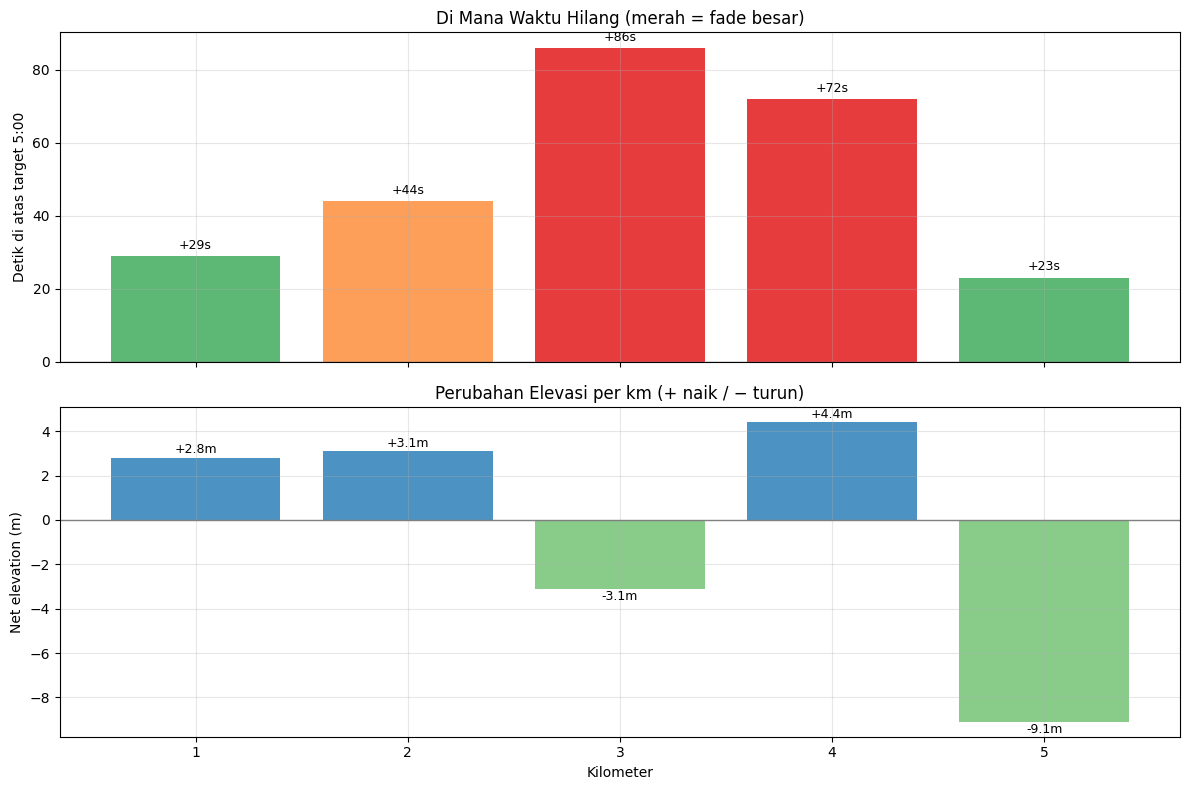

In [5]:
# Visual: pace loss vs elevation per km (diagnosis terrain vs pacing)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

colors = ["#e31a1c" if l > 60 else "#fd8d3c" if l > 30 else "#41ab5d"
          for l in splits_df["loss_vs_target_s"]]
axes[0].bar(splits_df["km"], splits_df["loss_vs_target_s"], color=colors, alpha=0.85)
axes[0].axhline(0, color="gray", lw=1)
axes[0].set_ylabel("Detik di atas target 5:00")
axes[0].set_title("Di Mana Waktu Hilang (merah = fade besar)")
for _, r in splits_df.iterrows():
    axes[0].text(r["km"], r["loss_vs_target_s"]+2, f"+{r['loss_vs_target_s']:.0f}s",
                 ha="center", fontsize=9)
axes[0].grid(True, alpha=0.3)

# net elevation per km — kalau fade km TURUN, bukan terrain
ec = ["#2c7fb8" if e >= 0 else "#74c476" for e in splits_df["net_elev"]]
axes[1].bar(splits_df["km"], splits_df["net_elev"], color=ec, alpha=0.85)
axes[1].axhline(0, color="gray", lw=1)
axes[1].set_ylabel("Net elevation (m)")
axes[1].set_xlabel("Kilometer")
axes[1].set_title("Perubahan Elevasi per km (+ naik / − turun)")
for _, r in splits_df.iterrows():
    axes[1].text(r["km"], r["net_elev"]+(0.2 if r["net_elev"]>=0 else -0.5),
                 f"{r['net_elev']:+.1f}m", ha="center", fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()

from pathlib import Path as _P
save_dir = _P(f"../reports/{points[0].time.strftime('%Y')}/"
             f"{points[0].time.strftime('%B')}/runs")
save_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(save_dir / f"{run_date}_km_splits.png", dpi=150, bbox_inches="tight")
print(f"Tersimpan: {save_dir / f'{run_date}_km_splits.png'}")  # <-- nama file FIX (06-16)
plt.show()

In [6]:
# Diagnosis otomatis: terrain vs pacing untuk tiap km fade
print("DIAGNOSIS PER-KM:")
print("-" * 60)
for _, r in splits_df.iterrows():
    if r["loss_vs_target_s"] <= 30:
        verdict = "OK (dekat target)"
    elif r["net_elev"] < 0:
        verdict = "FADE di jalur TURUN -> pacing/fitness, BUKAN terrain"
    elif r["gain"] > 8:
        verdict = "ada tanjakan -> sebagian terrain"
    else:
        verdict = "flat tapi lambat -> pacing/fitness"
    print(f"  km{int(r['km'])}: +{r['loss_vs_target_s']:.0f}s, "
          f"net {r['net_elev']:+.1f}m, HR {r['avg_hr']:.0f} -> {verdict}")

DIAGNOSIS PER-KM:
------------------------------------------------------------
  km1: +29s, net +2.8m, HR 154 -> OK (dekat target)
  km2: +44s, net +3.1m, HR 178 -> ada tanjakan -> sebagian terrain
  km3: +86s, net -3.1m, HR 179 -> FADE di jalur TURUN -> pacing/fitness, BUKAN terrain
  km4: +72s, net +4.4m, HR 183 -> ada tanjakan -> sebagian terrain
  km5: +23s, net -9.1m, HR 187 -> OK (dekat target)


## 5. HR & Pace Timeline (Menit-per-Menit)

Tersimpan: ..\reports\2026\June\runs\2026-06-16_hr_pace_timeline.png


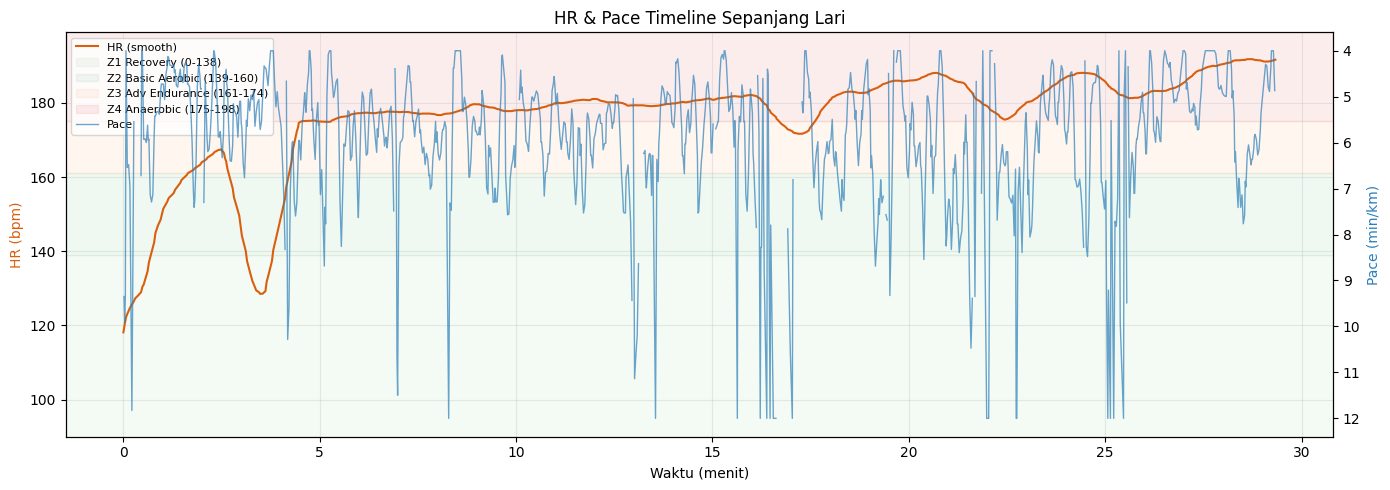

In [7]:
fig, ax1 = plt.subplots(figsize=(14, 5))

hr_smooth = df["hr"].rolling(30, center=True, min_periods=1).mean()
ax1.plot(df["elapsed_min"], hr_smooth, color="#d95f0e", linewidth=1.5, label="HR (smooth)")

# >>> CLAUDE FIX #3: zona Karvonen — sama persis dengan HR_ZONES setup
for name, (lo, hi) in HR_ZONES.items():
    ax1.axhspan(lo, hi, alpha=0.08, color=HR_ZONE_COLORS[name], label=f"{name} ({lo}-{hi-1})")

ax1.set_ylabel("HR (bpm)", color="#d95f0e")
ax1.set_ylim(90, 199)   # FIX: dulu 185, HR nyentuh 191 -> ke-clip
ax1.set_xlabel("Waktu (menit)")
ax1.set_title("HR & Pace Timeline Sepanjang Lari")
ax1.grid(True, alpha=0.25)

pace_plot = df["pace_min_km"].clip(4, 12)
ax2 = ax1.twinx()
ax2.plot(df["elapsed_min"], pace_plot, color="#2c7fb8", linewidth=1, alpha=0.7, label="Pace")
ax2.set_ylabel("Pace (min/km)", color="#2c7fb8")
ax2.invert_yaxis()

l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, loc="upper left", fontsize=8)

fig.tight_layout()
fig.savefig(save_dir / f"{run_date}_hr_pace_timeline.png", dpi=150, bbox_inches="tight")
print(f"Tersimpan: {save_dir / f'{run_date}_hr_pace_timeline.png'}")
plt.show()

## 6. Cardiac Drift (Paruh 1 vs Paruh 2)

Untuk **time trial** (effort maksimal), drift tinggi itu wajar — bukan tanda aerobik lemah.
Drift baru jadi sinyal masalah kalau muncul di easy/aerobic run.

HR paruh pertama : 169.5 bpm
HR paruh kedua   : 183.7 bpm
Cardiac drift    : +14.2 bpm

Konteks: ini TIME TRIAL (effort maks), jadi drift tinggi normal.
Drift baru jadi 'merah' kalau terjadi di easy/aerobic run.
Tersimpan: ..\reports\2026\June\runs\2026-06-16_cardiac_drift.png


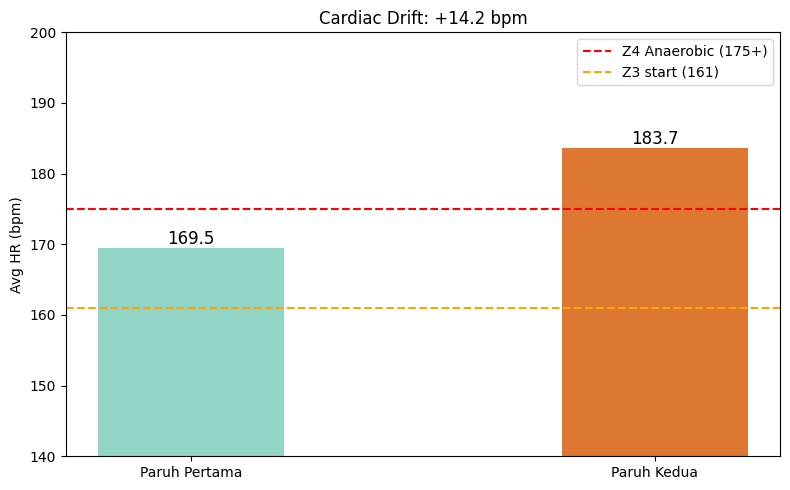

In [8]:
hrs = df["hr"].dropna().values
mid = len(hrs) // 2
hr_first  = hrs[:mid].mean()
hr_second = hrs[mid:].mean()
drift     = hr_second - hr_first

print(f"HR paruh pertama : {hr_first:.1f} bpm")
print(f"HR paruh kedua   : {hr_second:.1f} bpm")
print(f"Cardiac drift    : {drift:+.1f} bpm")
print()
print("Konteks: ini TIME TRIAL (effort maks), jadi drift tinggi normal.")
print("Drift baru jadi 'merah' kalau terjadi di easy/aerobic run.")

fig, ax = plt.subplots(figsize=(8, 5))
labels = ["Paruh Pertama", "Paruh Kedua"]
vals   = [hr_first, hr_second]
bars = ax.bar(labels, vals, color=["#7fcdbb", "#d95f0e"], width=0.4, alpha=0.85)

# >>> CLAUDE FIX #3: acuan zona Karvonen, bukan 152/140 lama
ax.axhline(175, color="red",    linestyle="--", label="Z4 Anaerobic (175+)")
ax.axhline(161, color="orange", linestyle="--", label="Z3 start (161)")
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.5, f"{val:.1f}", ha="center", fontsize=12)
ax.set_ylabel("Avg HR (bpm)")
ax.set_title(f"Cardiac Drift: {drift:+.1f} bpm")
ax.set_ylim(140, 200)   # FIX: dulu 130-175 -> meng-clip HR 184
ax.legend()

fig.tight_layout()
fig.savefig(save_dir / f"{run_date}_cardiac_drift.png", dpi=150, bbox_inches="tight")
print(f"Tersimpan: {save_dir / f'{run_date}_cardiac_drift.png'}")
plt.show()

## 7. Distribusi Zona HR (Karvonen)

Tersimpan: ..\reports\2026\June\runs\2026-06-16_zona_hr.png


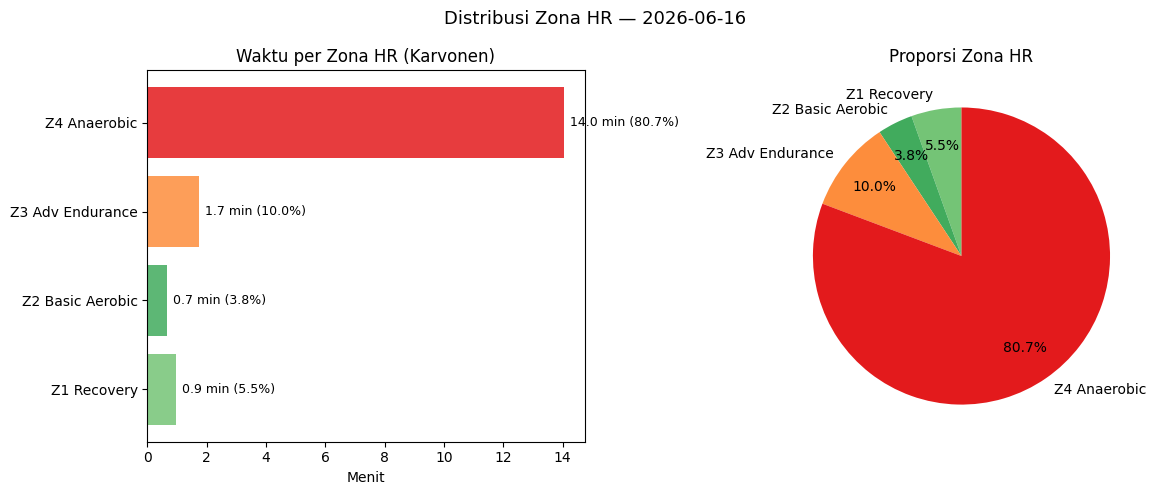


Ringkasan:
  Z1 Recovery         :   0.9 menit (5.5%)
  Z2 Basic Aerobic    :   0.7 menit (3.8%)
  Z3 Adv Endurance    :   1.7 menit (10.0%)
  Z4 Anaerobic        :  14.0 menit (80.7%)

Untuk time trial 5K, dominasi Z4 itu EKSPEKTASI yang benar.


In [9]:
hrs_all = df["hr"].dropna().values
total_s = len(hrs_all)

zona_names  = list(HR_ZONES.keys())
zona_colors = [HR_ZONE_COLORS[n] for n in zona_names]
zona_mins, zona_pcts = [], []
for name in zona_names:
    lo, hi = HR_ZONES[name]
    n = ((hrs_all >= lo) & (hrs_all < hi)).sum()
    zona_mins.append(n/60)
    zona_pcts.append(n/total_s*100)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(zona_names, zona_mins, color=zona_colors, alpha=0.85)
axes[0].set_xlabel("Menit")
axes[0].set_title("Waktu per Zona HR (Karvonen)")
for i, (v, p) in enumerate(zip(zona_mins, zona_pcts)):
    axes[0].text(v+0.2, i, f"{v:.1f} min ({p:.1f}%)", va="center", fontsize=9)

axes[1].pie(zona_pcts, labels=zona_names, colors=zona_colors,
            autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
            startangle=90, pctdistance=0.75)
axes[1].set_title("Proporsi Zona HR")
fig.suptitle(f"Distribusi Zona HR — {run_date}", fontsize=13)
fig.tight_layout()
fig.savefig(save_dir / f"{run_date}_zona_hr.png", dpi=150, bbox_inches="tight")
print(f"Tersimpan: {save_dir / f'{run_date}_zona_hr.png'}")
plt.show()

print("\nRingkasan:")
for name, mins, pct in zip(zona_names, zona_mins, zona_pcts):
    print(f"  {name:20s}: {mins:5.1f} menit ({pct:.1f}%)")
print("\nUntuk time trial 5K, dominasi Z4 itu EKSPEKTASI yang benar.")

## 8. Ringkasan Run

Tersimpan: ..\reports\2026\June\runs\2026-06-16_summary.png


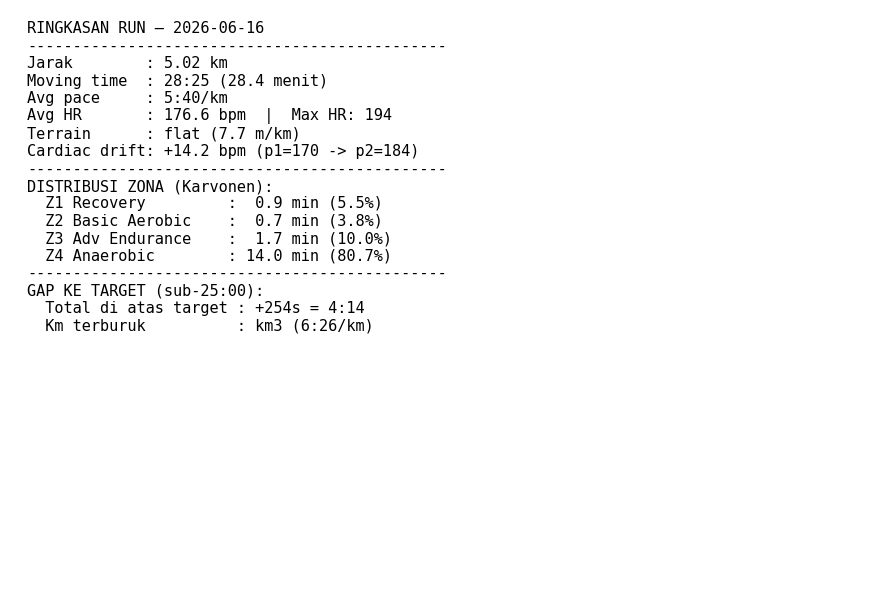

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.axis("off")

def fmt_pace(p):
    m = int(p); s = round((p-m)*60)
    if s == 60: m += 1; s = 0
    return f"{m}:{s:02d}"

sep = "-" * 46
txt = (
    f"RINGKASAN RUN — {run_date}\n{sep}\n"
    f"Jarak        : {total_dist:.2f} km\n"
    f"Moving time  : {fmt_pace(moving_min)} ({moving_min:.1f} menit)\n"
    f"Avg pace     : {fmt_pace(avg_pace)}/km\n"
    f"Avg HR       : {avg_hr:.1f} bpm  |  Max HR: {max_hr:.0f}\n"
    f"Terrain      : {terrain_final} ({gain_per_km:.1f} m/km)\n"
    f"Cardiac drift: {drift:+.1f} bpm (p1={hr_first:.0f} -> p2={hr_second:.0f})\n"
    f"{sep}\nDISTRIBUSI ZONA (Karvonen):\n"
)
for name, m, p in zip(zona_names, zona_mins, zona_pcts):
    txt += f"  {name:20s}: {m:4.1f} min ({p:.1f}%)\n"

total_loss = ((splits_df['pace'] - TARGET_PACE) * 60).sum()
txt += (
    f"{sep}\nGAP KE TARGET (sub-25:00):\n"
    f"  Total di atas target : +{total_loss:.0f}s = {fmt_pace(total_loss/60)}\n"
    f"  Km terburuk          : km{int(splits_df.loc[splits_df['pace'].idxmax(),'km'])} "
    f"({fmt_pace(splits_df['pace'].max())}/km)\n"
)

ax.text(0.02, 0.98, txt, fontsize=11, family="monospace",
        verticalalignment="top", transform=ax.transAxes)
fig.tight_layout()
fig.savefig(save_dir / f"{run_date}_summary.png", dpi=150, bbox_inches="tight")
print(f"Tersimpan: {save_dir / f'{run_date}_summary.png'}")
plt.show()